# 01 — Exploratory Data Analysis

Anime Score regression. Six visualizations covering the rubric's data-analysis requirements: target distribution, multi-label structure, conditional distributions, bivariate relationships, multivariate correlation, and temporal trend. Each figure is saved as a 300 dpi PNG to `figures/` for embedding in the report.

Dataset: `data/anime-dataset-2023.csv` from [dbdmobile/myanimelist-dataset](https://www.kaggle.com/datasets/dbdmobile/myanimelist-dataset).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The notebook lives in notebooks/, so step up one level for src/ and figures/.
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# Reuse the loader and the duration parser from src so the cleanup logic stays
# in one place. We duplicate a few feature-engineering steps inline below
# (start_year, log counts) so the plots can reference them without running
# the full pipeline.
from src.preprocess import load_raw, _parse_duration

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def savefig(name):
    """Save the current figure to figures/ at 300 dpi for the report."""
    plt.savefig(FIG_DIR / name, dpi=300, bbox_inches='tight')
    print(f'saved {FIG_DIR / name}')

## Loading and basic summary

`load_raw` replaces the `"UNKNOWN"` sentinel with `NaN`, coerces the four stringified numeric columns, and drops rows where `Score` is missing or zero. The raw file holds **24,905** anime; after filtering we keep only those with a published community score.

In [2]:
raw_full = pd.read_csv(ROOT / 'data' / 'anime-dataset-2023.csv')
print('Raw shape:', raw_full.shape)
df = load_raw(ROOT / 'data' / 'anime-dataset-2023.csv')
print('After UNKNOWN cleanup + Score>0 filter:', df.shape)
print()
print('Score summary:')
print(df['Score'].describe().round(3))

Raw shape: (24905, 24)
After UNKNOWN cleanup + Score>0 filter: (15692, 24)

Score summary:
count    15692.000
mean         6.381
std          0.929
min          1.850
25%          5.730
50%          6.390
75%          7.060
max          9.100
Name: Score, dtype: float64


In [3]:
missing = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing[missing > 0].to_frame('% missing')

,% missing
Premiered,71.65
Licensors,69.95
English name,48.73
Producers,38.79
Studios,22.48
Rank,19.06
Genres,11.17
Rating,0.60
Episodes,0.56
Other name,0.25


In [4]:
# Inline feature engineering for the EDA plots only: derive start_year,
# Duration_min, and log-engagement columns directly on the cleaned df. This
# mirrors what src.preprocess.engineer_features does later, but without the
# one-hot encoding so the plots can keep Type and Genres as readable strings.
df['start_year'] = df['Aired'].astype(str).str.extract(r'(\d{4})').astype(float)
df['Duration_min'] = df['Duration'].apply(_parse_duration)
for c in ['Members', 'Favorites', 'Scored By']:
    df[f'log_{c.replace(" ", "_")}'] = np.log1p(pd.to_numeric(df[c], errors='coerce'))
df['Episodes'] = pd.to_numeric(df['Episodes'], errors='coerce')
df.head(2)

,anime_id,Name,English name,Other name,Score,Genres,Synopsis,Type,Episodes,Aired,...,Popularity,Favorites,Scored By,Members,Image URL,start_year,Duration_min,log_Members,log_Favorites,log_Scored_By
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,8.75,"Action, Award Winning, Sci-Fi","Crime is timeless. By the year 2071, humanity ...",TV,26.0,"Apr 3, 1998 to Apr 24, 1999",...,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...,1998.0,24.0,14.387341,11.271185,13.725798
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,8.38,"Action, Sci-Fi","Another day, another bounty—such is the life o...",Movie,1.0,"Sep 1, 2001",...,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...,2001.0,115.0,12.796575,7.278629,12.236839


## Plot 1 — Score distribution

The MAL Score is roughly bell-shaped and centered just above 6.5, with a longer left tail than right. Most anime cluster between 6 and 8; truly bad (<4) and truly elite (>8.5) entries are rare. This shape motivates RMSE/MAE as our primary metrics rather than classification accuracy, and tells us the **null baseline** (predicting the mean for every show) will hover around RMSE ≈ standard deviation of the score column. Any model worth its weight has to beat that null baseline by a clear margin.

saved C:\My Random Things\Claude\MLFinals\figures\01_score_dist.png


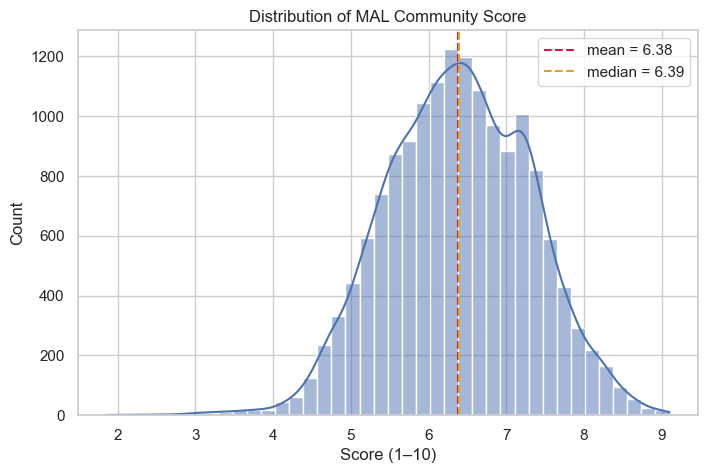

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['Score'], bins=40, kde=True, ax=ax, color='#4c72b0')
mean_, median_ = df['Score'].mean(), df['Score'].median()
ax.axvline(mean_, color='crimson', linestyle='--', label=f'mean = {mean_:.2f}')
ax.axvline(median_, color='goldenrod', linestyle='--', label=f'median = {median_:.2f}')
ax.set_title('Distribution of MAL Community Score')
ax.set_xlabel('Score (1\u201310)')
ax.set_ylabel('Count')
ax.legend()
savefig('01_score_dist.png')
plt.show()

## Plot 2 — Top 15 genre frequency

Genres are a comma-separated multi-label field; an anime can belong to several at once. Plotting the most common labels confirms the multi-label structure (Comedy, Action, Fantasy, Adventure dominate) and motivates the use of `MultiLabelBinarizer` rather than one-hot or label encoding. Since several genres carry score signal of their own (e.g. niche genres tend to skew higher because only invested fans rate them), preserving the full genre vector matters.

saved C:\My Random Things\Claude\MLFinals\figures\02_top_genres.png


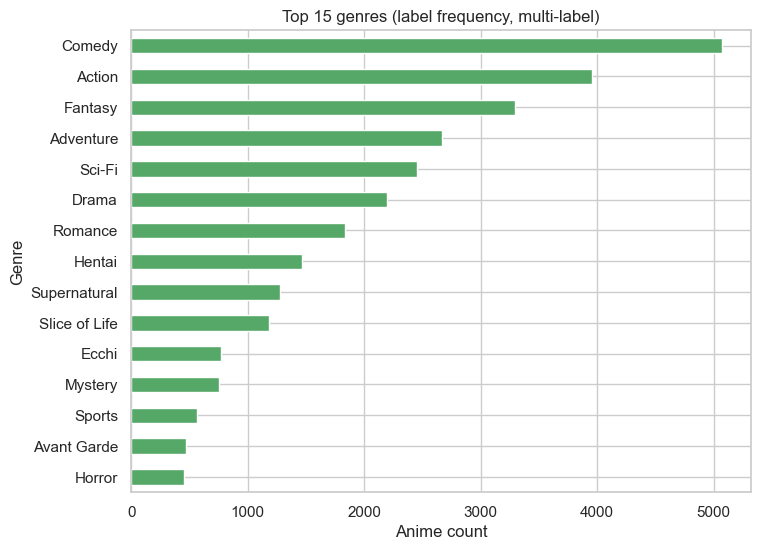

In [6]:
# Genres is comma-separated. Explode the list-of-genres into a flat Series
# of genre labels, then count to get global label frequency. Each anime
# typically contributes ~3 genres so the totals here add up to more than the
# row count.
genre_lists = df['Genres'].fillna('').apply(lambda s: [g.strip() for g in str(s).split(',') if g.strip()])
exploded = pd.Series([g for lst in genre_lists for g in lst])
top_genres = exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_genres[::-1].plot.barh(ax=ax, color='#55a868')
ax.set_title('Top 15 genres (label frequency, multi-label)')
ax.set_xlabel('Anime count')
ax.set_ylabel('Genre')
savefig('02_top_genres.png')
plt.show()

## Plot 3 — Score by Type

The `Type` field (TV, Movie, OVA, Special, ONA, Music) has visibly different score distributions. Movies and TV trend slightly higher with a tighter spread, while Music videos and ONAs span a much wider range and skew lower. This justifies treating `Type` as a one-hot feature rather than dropping it: the Type-conditional median can shift by half a score point or more, which is a meaningful chunk of an RMSE budget around 0.6.

saved C:\My Random Things\Claude\MLFinals\figures\03_score_by_type.png


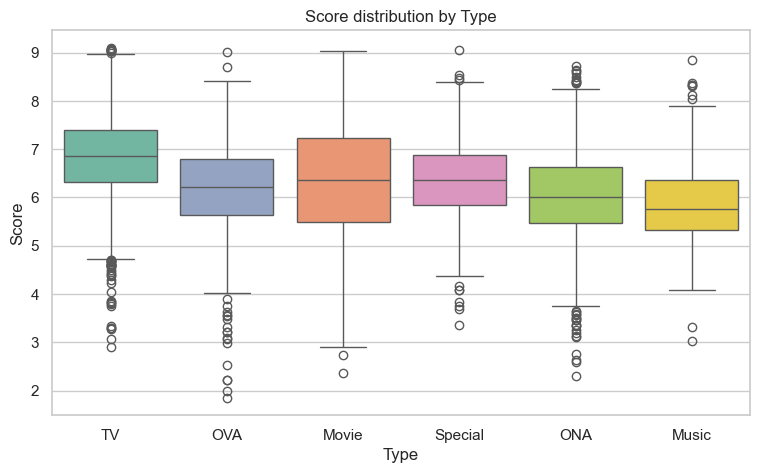

In [7]:
type_order = df['Type'].dropna().value_counts().index.tolist()
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Type', y='Score', order=type_order, ax=ax,
            palette='Set2', hue='Type', legend=False)
ax.set_title('Score distribution by Type')
ax.set_xlabel('Type')
ax.set_ylabel('Score')
savefig('03_score_by_type.png')
plt.show()

## Plot 4 — log(Members) vs Score, colored by Type

This is the single most important EDA plot for the leakage discussion in the report. There is a clear positive slope: anime with more members tend to score higher. The relationship is monotonic but not deterministic. Because the MAL Score formula is a Bayesian-weighted average that down-weights low-vote anime, the engagement counters (Members, Favorites, Scored By) are correlated with Score by construction. We keep them in the full-feature model but run a leakage-ablation experiment in the modeling notebook to measure how much of the predictive signal disappears once they are removed.

saved C:\My Random Things\Claude\MLFinals\figures\04_members_vs_score.png


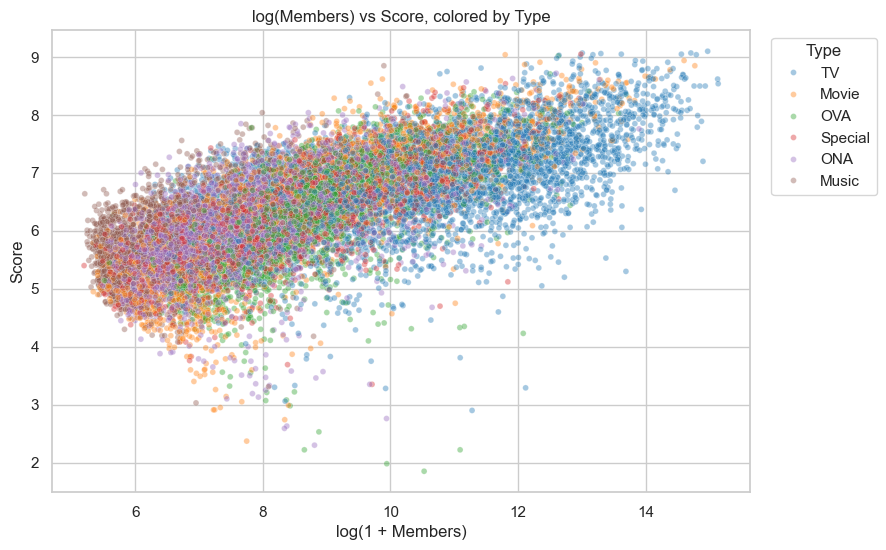

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x='log_Members', y='Score', hue='Type',
                alpha=0.4, s=18, ax=ax, palette='tab10')
ax.set_title('log(Members) vs Score, colored by Type')
ax.set_xlabel('log(1 + Members)')
ax.set_ylabel('Score')
ax.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
savefig('04_members_vs_score.png')
plt.show()

## Plot 5 — Numeric correlation heatmap

log_Members, log_Favorites, and log_Scored_By are tightly inter-correlated (r > 0.85) — they essentially measure the same latent variable, audience size. Score correlates moderately with all three. start_year is mildly negatively correlated with score (a small temporal drift; see plot 6). This multicollinearity is the textbook reason to use Ridge over OLS: ordinary least squares would split the engagement signal arbitrarily across the three columns, while Ridge's L2 penalty distributes coefficients more sensibly.

saved C:\My Random Things\Claude\MLFinals\figures\05_corr_heatmap.png


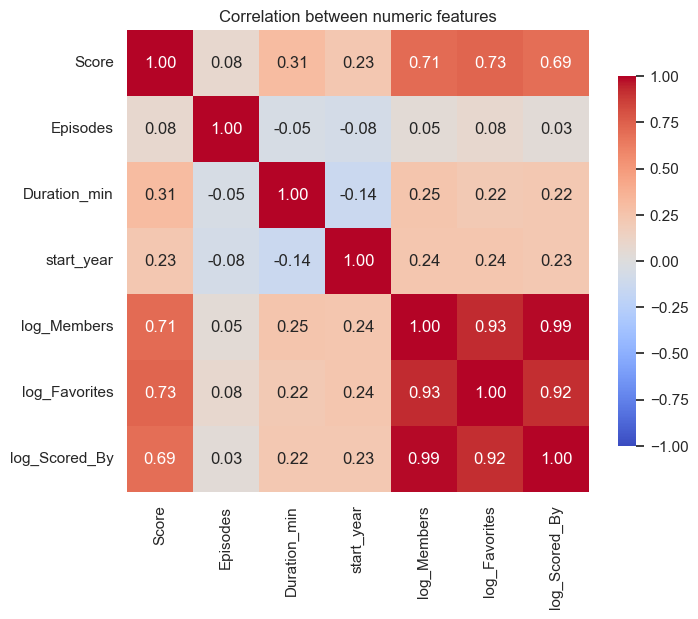

In [9]:
num_cols = ['Score', 'Episodes', 'Duration_min', 'start_year',
            'log_Members', 'log_Favorites', 'log_Scored_By']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation between numeric features')
savefig('05_corr_heatmap.png')
plt.show()

## Plot 6 — Mean Score over time

Aggregating mean score by `start_year` reveals a clear upward drift since the late 1960s — mean score climbs from roughly 5.5 in early decades to 6.8 in the 2020s. Two effects combine: survivorship bias (forgotten older anime drop out of the dataset, leaving mostly enduring favorites among very-old entries) and modern audience expansion (engaged communities rate recent shows more generously, and the explosion of niche, well-targeted releases lifts the average). The drift is large enough that a model ignoring release year would systematically under-predict recent anime, which is why `start_year` is kept as a numeric feature.

saved C:\My Random Things\Claude\MLFinals\figures\06_score_by_year.png


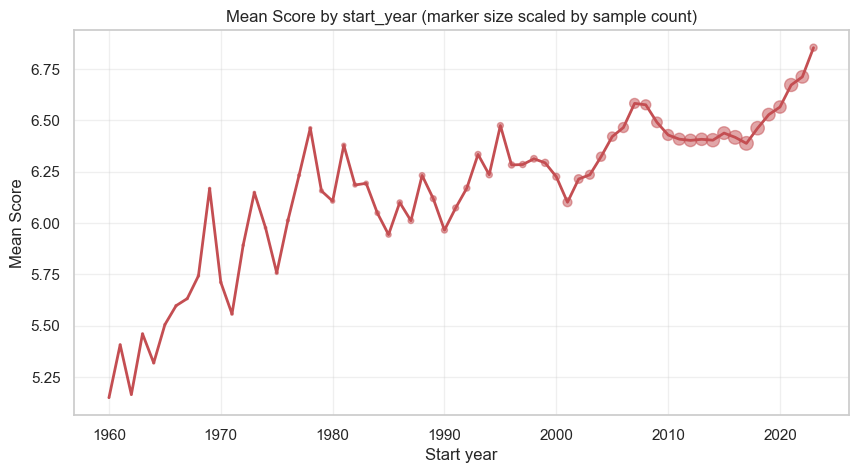

In [10]:
# Filter to years with at least 5 scored anime so a single ancient OVA
# doesn't yank the line. Marker size is proportional to sample count which
# helps the eye discount the noisy early decades.
yearly = df.dropna(subset=['start_year']).groupby('start_year')['Score'].agg(['mean', 'count'])
yearly = yearly[(yearly.index >= 1960) & (yearly.index <= 2024) & (yearly['count'] >= 5)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly.index, yearly['mean'], color='#c44e52', linewidth=2)
ax.scatter(yearly.index, yearly['mean'], s=yearly['count']/8, color='#c44e52', alpha=0.5)
ax.set_title('Mean Score by start_year (marker size scaled by sample count)')
ax.set_xlabel('Start year')
ax.set_ylabel('Mean Score')
ax.grid(True, alpha=0.3)
savefig('06_score_by_year.png')
plt.show()

## EDA takeaways

1. Score is bell-shaped, centered ~6.5, std ~0.9. Null baseline RMSE ≈ 0.9.
2. Genres are multi-label and worth preserving via `MultiLabelBinarizer`.
3. Type carries a non-trivial conditional shift in score — keep as one-hot.
4. Engagement features (Members, Favorites, Scored By) are highly correlated with each other and with Score. Log-transform and run a leakage ablation.
5. Year carries a mild trend; keep `start_year` as a numeric.

All six figures are now saved at 300 dpi under `figures/`. The modeling notebook (`02_modeling.ipynb`) picks up from here.